In [9]:
import pandas as pd

df = pd.read_csv(r"D:\Dataset\Internship Fraud Detection\alerts.csv")

df.columns

Index(['alert_id', 'transaction_id', 'customer_id', 'alert_type', 'severity',
       'timestamp', 'is_resolved'],
      dtype='object')

In [10]:
df

,alert_id,transaction_id,customer_id,alert_type,severity,timestamp,is_resolved
0,ALT_079681,TX_00079681,CUST_007451,High Amount,High,2026-08-17 00:15:46.462118,True
1,ALT_045971,TX_00045971,CUST_001232,New Device,Critical,2026-08-24 02:20:38.266080,True
2,ALT_095835,TX_00095835,CUST_002090,Unusual Time,Low,2026-08-29 18:36:50.122852,True
3,ALT_025868,TX_00025868,CUST_003270,New Device,Low,2026-08-27 17:50:33.578256,True
4,ALT_027966,TX_00027966,CUST_009474,Unusual Time,Medium,2026-09-02 14:15:34.057282,True
...,...,...,...,...,...,...,...
4995,ALT_011481,TX_00011481,CUST_000948,High Amount,High,2026-08-04 05:09:30.281754,False
4996,ALT_086059,TX_00086059,CUST_008245,High Amount,Medium,2026-08-08 11:59:47.914110,False
4997,ALT_029598,TX_00029598,CUST_002021,High Amount,Medium,2026-08-24 18:16:34.423839,True
4998,ALT_077222,TX_00077222,CUST_007000,New Device,Critical,2026-08-20 03:40:45.821913,True


In [5]:
df["investigator"] = df["investigator"].fillna("Not Assigned")

In [7]:
df.to_csv(r"D:\Dataset\Internship Fraud Detection\fraud_cases_cleaned.csv", index=False)

print("CSV saved successfully!")

CSV saved successfully!


In [5]:
df.dtypes

transaction_id           str
customer_id              str
amount               float64
timestamp                str
hour                   int64
day_of_week            int64
location                 str
merchant_category        str
is_new_device           bool
device_id                str
ip_address               str
is_fraud               int64
transaction_type         str
card_present            bool
amount_log           float64
is_weekend             int64
dtype: object

In [6]:
df.isnull().sum()

transaction_id       0
customer_id          0
amount               0
timestamp            0
hour                 0
day_of_week          0
location             0
merchant_category    0
is_new_device        0
device_id            0
ip_address           0
is_fraud             0
transaction_type     0
card_present         0
amount_log           0
is_weekend           0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.shape

(99106, 16)

In [8]:
df.isnull().sum()

transaction_id       0
customer_id          0
amount               0
timestamp            0
hour                 0
day_of_week          0
location             0
merchant_category    0
is_new_device        0
device_id            0
ip_address           0
is_fraud             0
transaction_type     0
card_present         0
amount_log           0
is_weekend           0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df['is_fraud'].value_counts()

is_fraud
0    98045
1     1061
Name: count, dtype: int64

In [12]:
df['is_fraud'].value_counts(normalize=True) * 100

is_fraud
0    98.929429
1     1.070571
Name: proportion, dtype: float64

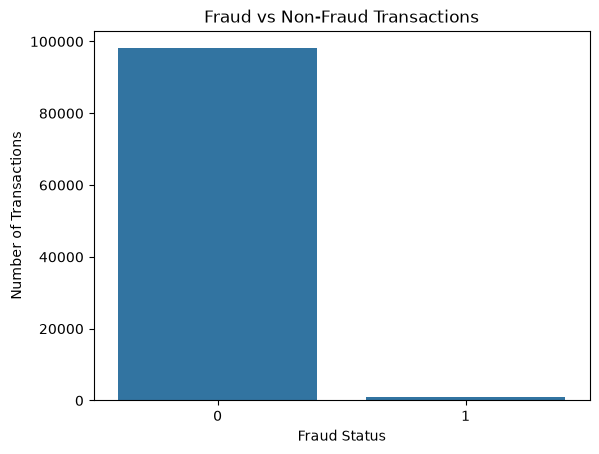

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(data=df, x='is_fraud')

plt.title("Fraud vs Non-Fraud Transactions")
plt.xlabel("Fraud Status")
plt.ylabel("Number of Transactions")

plt.show()

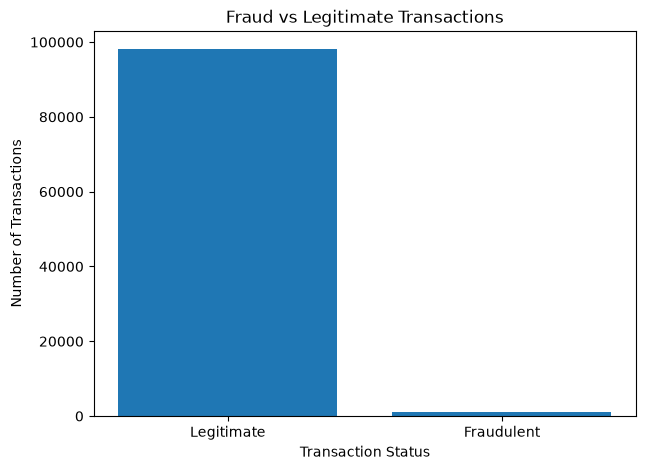

In [15]:
fraud_counts = df['is_fraud'].value_counts()

plt.figure(figsize=(7,5))

plt.bar(
    ['Legitimate', 'Fraudulent'],
    [fraud_counts[0], fraud_counts[1]]
)

plt.title("Fraud vs Legitimate Transactions")
plt.xlabel("Transaction Status")
plt.ylabel("Number of Transactions")

plt.show()

In [16]:
df['is_fraud'].value_counts(normalize=True) * 100

is_fraud
0    98.929429
1     1.070571
Name: proportion, dtype: float64

In [17]:
df.groupby('is_fraud')['amount'].agg(
    ['count', 'mean', 'median', 'min', 'max']
)

,count,mean,median,min,max
is_fraud,,,,,
0,98045,2503.656097,1874.77,5.01,9935.39
1,1061,16243.367107,16011.63,507.56,34385.20


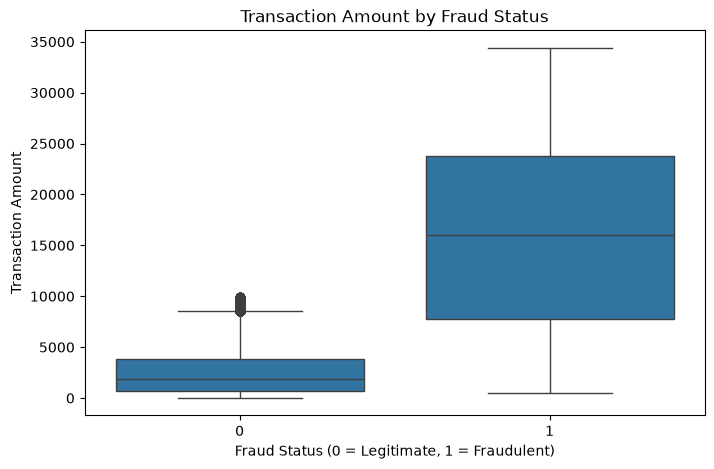

In [18]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='is_fraud',
    y='amount'
)

plt.title("Transaction Amount by Fraud Status")
plt.xlabel("Fraud Status (0 = Legitimate, 1 = Fraudulent)")
plt.ylabel("Transaction Amount")

plt.show()

In [18]:
df.groupby('is_fraud')['amount'].agg(
    ['count', 'mean', 'median', 'min', 'max']
)

,count,mean,median,min,max
is_fraud,,,,,
0,98045,2503.656097,1874.77,5.01,9935.39
1,1061,16243.367107,16011.63,507.56,34385.20


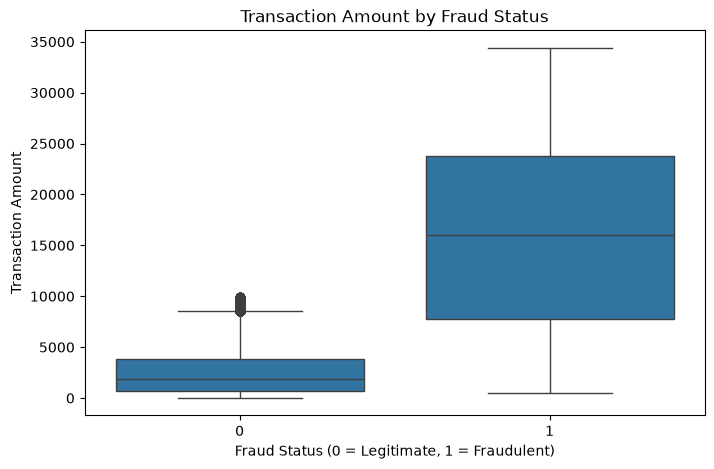

In [19]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='is_fraud',
    y='amount'
)

plt.title("Transaction Amount by Fraud Status")
plt.xlabel("Fraud Status (0 = Legitimate, 1 = Fraudulent)")
plt.ylabel("Transaction Amount")

plt.show()

In [20]:
transaction_analysis = df.groupby('transaction_type').agg(
    total_transactions=('is_fraud', 'count'),
    fraud_transactions=('is_fraud', 'sum'),
    fraud_rate=('is_fraud', 'mean')
)

transaction_analysis['fraud_rate'] *= 100

transaction_analysis.sort_values('fraud_rate', ascending=False)

,total_transactions,fraud_transactions,fraud_rate
transaction_type,,,
online,24647,302,1.225301
atm,24808,269,1.084328
in-store,24712,245,0.991421
wire,24939,245,0.982397


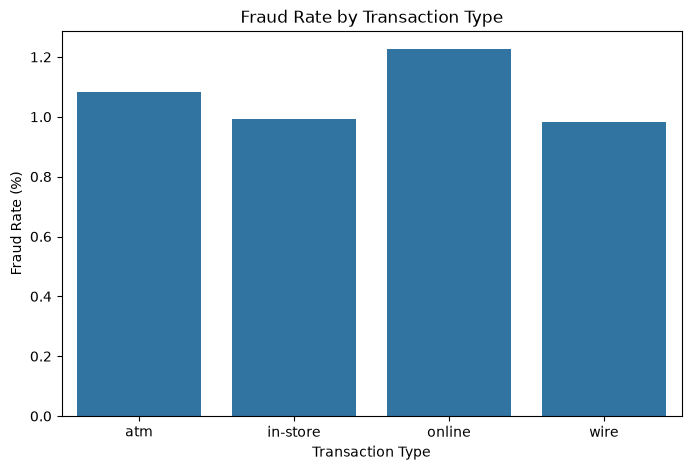

In [21]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=transaction_analysis.reset_index(),
    x='transaction_type',
    y='fraud_rate'
)

plt.title("Fraud Rate by Transaction Type")
plt.xlabel("Transaction Type")
plt.ylabel("Fraud Rate (%)")

plt.show()

In [22]:
hour_analysis = df.groupby('hour').agg(
    total_transactions=('is_fraud', 'count'),
    fraud_transactions=('is_fraud', 'sum'),
    fraud_rate=('is_fraud', 'mean')
)

hour_analysis['fraud_rate'] *= 100

hour_analysis

,total_transactions,fraud_transactions,fraud_rate
hour,,,
0,57,57,100.000000
1,50,50,100.000000
2,54,54,100.000000
3,60,60,100.000000
6,6201,41,0.661184
7,6231,54,0.866635
8,6081,42,0.690676
9,6113,43,0.703419
10,6367,46,0.722475


In [23]:
df[df['hour'].isin([0, 1, 2, 3, 22, 23])][
    ['timestamp', 'hour', 'amount', 'transaction_type', 'is_fraud']
].head(20)

,timestamp,hour,amount,transaction_type,is_fraud
120,2026-08-19 00:43:27.401235,23,28093.77,online,1
312,2026-08-30 02:06:27.455392,3,27720.30,wire,1
463,2026-08-31 16:06:27.498479,0,16284.70,wire,1
860,2026-09-02 17:37:27.625585,2,24786.06,atm,1
1154,2026-08-16 21:59:27.701887,0,21921.24,online,1
1892,2026-08-20 08:10:27.910630,22,33634.29,online,1
2580,2026-08-30 03:19:28.104480,3,2399.01,online,1
2771,2026-08-04 15:37:28.159118,2,16131.12,atm,1
3055,2026-08-04 09:34:28.230748,1,19928.26,atm,1
3390,2026-08-10 00:18:28.317310,22,7099.07,wire,1


In [24]:
df['timestamp'] = pd.to_datetime(df['timestamp'])

df['actual_hour'] = df['timestamp'].dt.hour

df[['timestamp', 'hour', 'actual_hour']].head(20)

,timestamp,hour,actual_hour
0,2026-08-29 11:13:27.372050,16,11
1,2026-08-22 01:00:27.372684,7,1
2,2026-08-22 04:53:27.372963,21,4
3,2026-09-02 18:32:27.373252,21,18
4,2026-08-30 00:06:27.373504,10,0
5,2026-08-07 11:44:27.373744,7,11
6,2026-08-07 10:03:27.373979,14,10
7,2026-08-25 12:50:27.374214,20,12
8,2026-08-29 20:47:27.374499,11,20
9,2026-08-08 04:00:27.374737,12,4


In [25]:
(df['hour'] != df['actual_hour']).sum()

np.int64(94938)

In [26]:
actual_hour_analysis = df.groupby('actual_hour').agg(
    total_transactions=('is_fraud', 'count'),
    fraud_transactions=('is_fraud', 'sum'),
    fraud_rate=('is_fraud', 'mean')
)

actual_hour_analysis['fraud_rate'] *= 100

actual_hour_analysis

,total_transactions,fraud_transactions,fraud_rate
actual_hour,,,
0,4138,59,1.425810
1,4077,44,1.079225
2,4128,47,1.138566
3,4216,48,1.138520
4,4093,52,1.270462
5,4100,44,1.073171
6,4170,35,0.839329
7,4202,40,0.951928
8,4179,44,1.052883


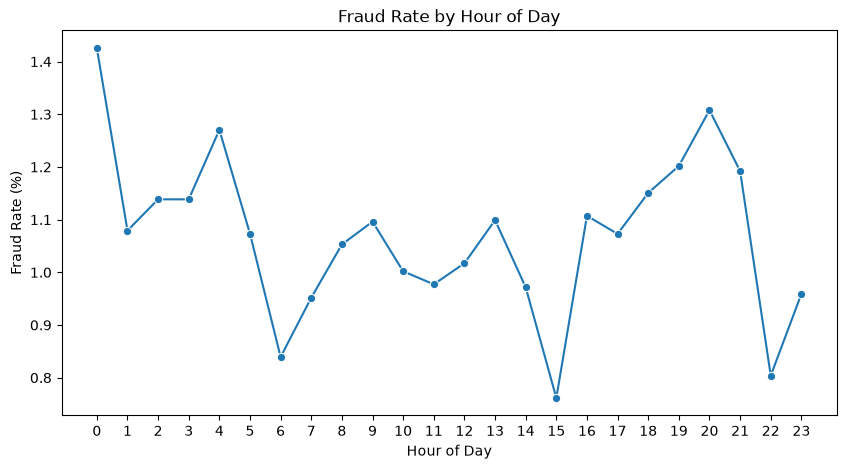

In [27]:
plt.figure(figsize=(10,5))

sns.lineplot(
    data=actual_hour_analysis.reset_index(),
    x='actual_hour',
    y='fraud_rate',
    marker='o'
)

plt.title("Fraud Rate by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Fraud Rate (%)")
plt.xticks(range(24))

plt.show()

In [28]:
df['day_of_week'].value_counts().sort_index()

day_of_week
0    14228
1    14012
2    14157
3    14199
4    14090
5    14279
6    14141
Name: count, dtype: int64

In [29]:
day_analysis = df.groupby('day_of_week').agg(
    total_transactions=('is_fraud', 'count'),
    fraud_transactions=('is_fraud', 'sum'),
    fraud_rate=('is_fraud', 'mean')
)

day_analysis['fraud_rate'] *= 100

day_analysis

,total_transactions,fraud_transactions,fraud_rate
day_of_week,,,
0,14228,141,0.991004
1,14012,156,1.113331
2,14157,146,1.031292
3,14199,152,1.070498
4,14090,158,1.121363
5,14279,165,1.155543
6,14141,143,1.011244


In [30]:
df['actual_day_of_week'] = df['timestamp'].dt.dayofweek

(df['day_of_week'] != df['actual_day_of_week']).sum()

np.int64(84795)

In [31]:
actual_day_analysis = df.groupby('actual_day_of_week').agg(
    total_transactions=('is_fraud', 'count'),
    fraud_transactions=('is_fraud', 'sum'),
    fraud_rate=('is_fraud', 'mean')
)

actual_day_analysis['fraud_rate'] *= 100

actual_day_analysis

,total_transactions,fraud_transactions,fraud_rate
actual_day_of_week,,,
0,13739,140,1.018997
1,16303,191,1.171564
2,16075,174,1.082426
3,13319,135,1.013590
4,13302,128,0.962261
5,13146,139,1.057356
6,13222,154,1.164725


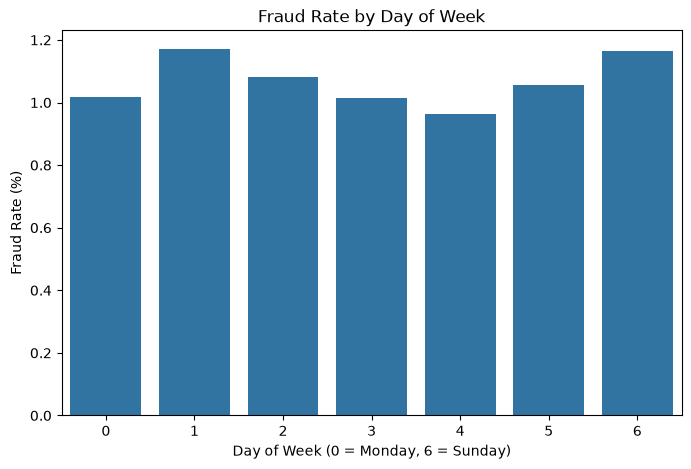

In [32]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=actual_day_analysis.reset_index(),
    x='actual_day_of_week',
    y='fraud_rate'
)

plt.title("Fraud Rate by Day of Week")
plt.xlabel("Day of Week (0 = Monday, 6 = Sunday)")
plt.ylabel("Fraud Rate (%)")

plt.show()

In [36]:
customers = pd.read_csv("customers_cleaned.csv")

customers.head()

,customer_id,segment,account_age_days,risk_score,email_verified,phone_verified,avg_monthly_transactions,avg_transaction_amount,device_count,location
0,CUST_000000,Retail,2332,0.697657,True,True,45,2064.757168,3,US
1,CUST_000001,Retail,531,0.588541,True,True,83,3040.637196,4,IN
2,CUST_000002,Business,1974,0.364320,True,True,9,2079.751870,1,US
3,CUST_000003,Retail,1852,0.454465,True,True,94,1135.531920,3,IN
4,CUST_000004,Business,2185,0.631022,False,True,94,3991.774005,2,IN


In [34]:
import os

os.getcwd()

'C:\\Users\\K sri bhavya\\Desktop\\Financial_Fraud_Detection'

In [35]:
os.listdir()

['.ipynb_checkpoints',
 'fraud_cases.csv',
 'paysim_transactions.csv',
 'paysim_transactions_cleaned.csv',
 'Untitled.ipynb']

In [37]:
customers.shape

(10000, 10)

In [38]:
print("Unique customer IDs in customers:", customers['customer_id'].nunique())
print("Unique customer IDs in transactions:", df['customer_id'].nunique())

Unique customer IDs in customers: 10000
Unique customer IDs in transactions: 9999


In [39]:
missing_customer_ids = set(customers['customer_id']) - set(df['customer_id'])

missing_customer_ids

{'CUST_004045'}

In [40]:
missing_transaction_customers = set(df['customer_id']) - set(customers['customer_id'])

missing_transaction_customers

set()

In [41]:
customers['customer_id'].duplicated().sum()

np.int64(0)

In [42]:
df_merged = df.merge(
    customers,
    on='customer_id',
    how='left'
)

df_merged.head()

,transaction_id,customer_id,amount,timestamp,hour,day_of_week,location_x,merchant_category,is_new_device,device_id,...,actual_day_of_week,segment,account_age_days,risk_score,email_verified,phone_verified,avg_monthly_transactions,avg_transaction_amount,device_count,location_y
0,TX_00000000,CUST_005287,807.91,2026-08-29 11:13:27.372050,16,5,US,Food,False,DEV_4390,...,5,Retail,1394,0.520467,True,True,52,799.728774,3,US
1,TX_00000001,CUST_002180,734.39,2026-08-22 01:00:27.372684,7,4,UK,Retail,False,DEV_4068,...,5,Retail,256,0.592291,True,True,51,1358.790483,3,UK
2,TX_00000002,CUST_006491,2080.84,2026-08-22 04:53:27.372963,21,3,US,E-commerce,False,DEV_1115,...,5,Business,968,0.512422,True,True,75,1543.891662,3,US
3,TX_00000003,CUST_008714,2521.49,2026-09-02 18:32:27.373252,21,3,UK,E-commerce,False,DEV_2305,...,2,Retail,2621,0.451517,False,False,8,2417.631163,1,UK
4,TX_00000004,CUST_004620,1802.67,2026-08-30 00:06:27.373504,10,4,IN,Food,False,DEV_4547,...,6,Retail,2281,0.452063,False,True,56,3872.284181,4,IN


In [43]:
df_merged.shape

(99106, 27)

In [44]:
df_merged.isnull().sum()

transaction_id              0
customer_id                 0
amount                      0
timestamp                   0
hour                        0
day_of_week                 0
location_x                  0
merchant_category           0
is_new_device               0
device_id                   0
ip_address                  0
is_fraud                    0
transaction_type            0
card_present                0
amount_log                  0
is_weekend                  0
actual_hour                 0
actual_day_of_week          0
segment                     0
account_age_days            0
risk_score                  0
email_verified              0
phone_verified              0
avg_monthly_transactions    0
avg_transaction_amount      0
device_count                0
location_y                  0
dtype: int64

In [45]:
df_merged.duplicated().sum()

np.int64(0)

In [46]:
df_merged.columns.tolist()

['transaction_id',
 'customer_id',
 'amount',
 'timestamp',
 'hour',
 'day_of_week',
 'location_x',
 'merchant_category',
 'is_new_device',
 'device_id',
 'ip_address',
 'is_fraud',
 'transaction_type',
 'card_present',
 'amount_log',
 'is_weekend',
 'actual_hour',
 'actual_day_of_week',
 'segment',
 'account_age_days',
 'risk_score',
 'email_verified',
 'phone_verified',
 'avg_monthly_transactions',
 'avg_transaction_amount',
 'device_count',
 'location_y']

In [47]:
df_merged['is_fraud'].value_counts()

is_fraud
0    98045
1     1061
Name: count, dtype: int64

In [48]:
segment_analysis = df_merged.groupby('segment').agg(
    total_transactions=('is_fraud', 'count'),
    fraud_transactions=('is_fraud', 'sum'),
    fraud_rate=('is_fraud', 'mean')
)

segment_analysis['fraud_rate'] *= 100

segment_analysis

,total_transactions,fraud_transactions,fraud_rate
segment,,,
Business,29687,315,1.061071
Premium,19453,223,1.146353
Retail,40364,425,1.052918
Student,9602,98,1.020621


In [49]:
df_merged.groupby('is_fraud')['risk_score'].agg(
    ['count', 'mean', 'median', 'min', 'max']
)

,count,mean,median,min,max
is_fraud,,,,,
0,98045,0.495952,0.496254,0.0,1.0
1,1061,0.490808,0.483848,0.0,1.0


In [50]:
df_merged['risk_group'] = pd.cut(
    df_merged['risk_score'],
    bins=[0, 0.2, 0.4, 0.6, 0.8, 1.0],
    labels=['Very Low', 'Low', 'Medium', 'High', 'Very High']
)

risk_analysis = df_merged.groupby('risk_group', observed=False).agg(
    total_transactions=('is_fraud', 'count'),
    fraud_transactions=('is_fraud', 'sum'),
    fraud_rate=('is_fraud', 'mean')
)

risk_analysis['fraud_rate'] *= 100

risk_analysis

,total_transactions,fraud_transactions,fraud_rate
risk_group,,,
Very Low,2972,35,1.177658
Low,23189,262,1.129846
Medium,47588,491,1.031773
High,22697,255,1.123496
Very High,2566,17,0.662510


In [51]:
email_analysis = df_merged.groupby('email_verified').agg(
    total_transactions=('is_fraud', 'count'),
    fraud_transactions=('is_fraud', 'sum'),
    fraud_rate=('is_fraud', 'mean')
)

email_analysis['fraud_rate'] *= 100

email_analysis

,total_transactions,fraud_transactions,fraud_rate
email_verified,,,
False,19412,214,1.102411
True,79694,847,1.062815


In [52]:
phone_analysis = df_merged.groupby('phone_verified').agg(
    total_transactions=('is_fraud', 'count'),
    fraud_transactions=('is_fraud', 'sum'),
    fraud_rate=('is_fraud', 'mean')
)

phone_analysis['fraud_rate'] *= 100

phone_analysis

,total_transactions,fraud_transactions,fraud_rate
phone_verified,,,
False,29661,310,1.045143
True,69445,751,1.081431


In [53]:
df_merged.groupby('is_fraud')['account_age_days'].agg(
    ['count', 'mean', 'median', 'min', 'max']
)

,count,mean,median,min,max
is_fraud,,,,,
0,98045,1824.842256,1819.0,30,3649
1,1061,1896.068803,1887.0,38,3644


In [54]:
device_analysis = df_merged.groupby('is_new_device').agg(
    total_transactions=('is_fraud', 'count'),
    fraud_transactions=('is_fraud', 'sum'),
    fraud_rate=('is_fraud', 'mean')
)

device_analysis['fraud_rate'] *= 100

device_analysis

,total_transactions,fraud_transactions,fraud_rate
is_new_device,,,
False,98783,738,0.747092
True,323,323,100.000000


In [55]:
merchant_analysis = df_merged.groupby('merchant_category').agg(
    total_transactions=('is_fraud', 'count'),
    fraud_transactions=('is_fraud', 'sum'),
    fraud_rate=('is_fraud', 'mean')
)

merchant_analysis['fraud_rate'] *= 100

merchant_analysis.sort_values('fraud_rate', ascending=False)

,total_transactions,fraud_transactions,fraud_rate
merchant_category,,,
E-commerce,16556,183,1.105339
Food,16455,179,1.087815
Entertainment,16546,177,1.069745
Travel,16493,175,1.061056
Services,16557,175,1.056955
Retail,16499,172,1.042487


In [56]:
card_analysis = df_merged.groupby('card_present').agg(
    total_transactions=('is_fraud', 'count'),
    fraud_transactions=('is_fraud', 'sum'),
    fraud_rate=('is_fraud', 'mean')
)

card_analysis['fraud_rate'] *= 100

card_analysis

,total_transactions,fraud_transactions,fraud_rate
card_present,,,
False,39866,426,1.068580
True,59240,635,1.071911


In [57]:
df_merged.groupby('is_fraud')['device_count'].agg(
    ['count', 'mean', 'median', 'min', 'max']
)

,count,mean,median,min,max
is_fraud,,,,,
0,98045,2.479331,2.0,1,4
1,1061,2.476909,2.0,1,4


In [58]:
df_merged.groupby('is_fraud')['avg_monthly_transactions'].agg(
    ['count', 'mean', 'median', 'min', 'max']
)

,count,mean,median,min,max
is_fraud,,,,,
0,98045,52.007935,52.0,5,99
1,1061,52.544769,52.0,5,99


In [59]:
df_merged.groupby('is_fraud')['avg_transaction_amount'].agg(
    ['count', 'mean', 'median', 'min', 'max']
)

,count,mean,median,min,max
is_fraud,,,,,
0,98045,2504.006985,2494.601466,10.078672,4999.921125
1,1061,2493.304203,2427.205142,13.906087,4993.551539


In [60]:
df_merged['location_match'] = (
    df_merged['location_x'] == df_merged['location_y']
)

df_merged.groupby('location_match')['is_fraud'].agg(
    ['count', 'sum', 'mean']
)

,count,sum,mean
location_match,,,
False,204,204,1.000000
True,98902,857,0.008665


In [61]:
pd.crosstab(
    df_merged['location_match'],
    df_merged['is_new_device']
)

is_new_device,False,True
location_match,,
False,138,66
True,98645,257


In [62]:
pd.crosstab(
    df_merged['is_new_device'],
    df_merged['is_fraud']
)

is_fraud,0,1
is_new_device,,
False,98045,738
True,0,323


In [63]:
df_merged[df_merged['is_new_device'] == True][
    ['transaction_id', 'customer_id', 'is_fraud', 'amount', 'timestamp',
     'location_x', 'location_y', 'transaction_type']
].head(20)

,transaction_id,customer_id,is_fraud,amount,timestamp,location_x,location_y,transaction_type
120,TX_00000122,CUST_001316,1,28093.77,2026-08-19 00:43:27.401235,NG,AU,online
151,TX_00000154,CUST_002611,1,12086.33,2026-08-07 09:24:27.409041,AU,AU,in-store
463,TX_00000467,CUST_001056,1,16284.70,2026-08-31 16:06:27.498479,US,US,wire
533,TX_00000537,CUST_006935,1,19587.69,2026-09-01 19:14:27.518288,US,US,online
1154,TX_00001166,CUST_002815,1,21921.24,2026-08-16 21:59:27.701887,UK,UK,online
1511,TX_00001528,CUST_008703,1,23567.34,2026-08-13 08:50:27.797169,RU,SG,atm
1556,TX_00001573,CUST_007325,1,9064.00,2026-08-31 18:32:27.809599,UK,UK,online
1575,TX_00001592,CUST_001188,1,1403.34,2026-09-02 09:27:27.814552,UK,UK,atm
2098,TX_00002122,CUST_008342,1,15346.88,2026-08-27 14:52:27.968616,NG,US,wire
2337,TX_00002362,CUST_003470,1,32717.24,2026-08-15 01:09:28.038216,SG,SG,online


In [64]:
df_merged.groupby('is_new_device')['amount'].agg(
    ['count', 'mean', 'median', 'min', 'max']
)

,count,mean,median,min,max
is_new_device,,,,,
False,98783,2605.241616,1898.37,5.01,34385.20
True,323,16568.396285,16517.87,601.52,34117.46


In [65]:
df_merged.groupby('location_match')['amount'].agg(
    ['count', 'mean', 'median', 'min', 'max']
)

,count,mean,median,min,max
location_match,,,,,
False,204,16711.982647,16114.190,1177.03,34385.20
True,98902,2621.746073,1901.885,5.01,34375.66


In [66]:
weekend_analysis = df_merged.groupby('is_weekend').agg(
    total_transactions=('is_fraud', 'count'),
    fraud_transactions=('is_fraud', 'sum'),
    fraud_rate=('is_fraud', 'mean')
)

weekend_analysis['fraud_rate'] *= 100

weekend_analysis

,total_transactions,fraud_transactions,fraud_rate
is_weekend,,,
0,70686,753,1.065275
1,28420,308,1.083744


In [67]:
location_analysis = df_merged.groupby('location_x').agg(
    total_transactions=('is_fraud', 'count'),
    fraud_transactions=('is_fraud', 'sum'),
    fraud_rate=('is_fraud', 'mean')
)

location_analysis['fraud_rate'] *= 100

location_analysis.sort_values('fraud_rate', ascending=False)

,total_transactions,fraud_transactions,fraud_rate
location_x,,,
BR,54,54,100.000000
NG,43,43,100.000000
CN,54,54,100.000000
RU,53,53,100.000000
SG,9978,100,1.002205
US,38593,348,0.901718
AU,10560,91,0.861742
IN,19497,162,0.830897
UK,20274,156,0.769458


In [68]:
pd.crosstab(
    [df_merged['is_new_device'], df_merged['location_match']],
    df_merged['is_fraud']
)

is_fraud                          0    1
is_new_device location_match            
False         False               0  138
              True            98045  600
True          False               0   66
              True                0  257

In [69]:
ip_analysis = df_merged.groupby('ip_address').agg(
    transaction_count=('transaction_id', 'count'),
    customer_count=('customer_id', 'nunique'),
    fraud_count=('is_fraud', 'sum'),
    fraud_rate=('is_fraud', 'mean')
)

ip_analysis['fraud_rate'] *= 100

ip_analysis.sort_values('transaction_count', ascending=False).head(10)

,transaction_count,customer_count,fraud_count,fraud_rate
ip_address,,,,
62.225.145.174,2,2,0,0.0
99.82.47.177,1,1,0,0.0
99.91.203.217,1,1,0,0.0
99.92.22.173,1,1,0,0.0
99.92.3.175,1,1,0,0.0
99.93.133.63,1,1,0,0.0
99.94.133.250,1,1,0,0.0
99.94.14.64,1,1,0,0.0
99.95.114.115,1,1,0,0.0


In [70]:
print("Unique IP addresses:", df_merged['ip_address'].nunique())
print("Unique device IDs:", df_merged['device_id'].nunique())
print("Total transactions:", len(df_merged))

Unique IP addresses: 99105
Unique device IDs: 4999
Total transactions: 99106


In [71]:
device_analysis = df_merged.groupby('device_id').agg(
    transaction_count=('transaction_id', 'count'),
    customer_count=('customer_id', 'nunique'),
    fraud_count=('is_fraud', 'sum'),
    fraud_rate=('is_fraud', 'mean')
)

device_analysis['fraud_rate'] *= 100

device_analysis.sort_values('transaction_count', ascending=False).head(10)

,transaction_count,customer_count,fraud_count,fraud_rate
device_id,,,,
DEV_0774,39,39,0,0.000000
DEV_1266,38,38,1,2.631579
DEV_0803,37,37,0,0.000000
DEV_1412,37,36,0,0.000000
DEV_1925,37,37,0,0.000000
DEV_4022,36,36,0,0.000000
DEV_0704,35,35,0,0.000000
DEV_0156,35,35,0,0.000000
DEV_0520,35,35,0,0.000000


In [72]:
shared_device_analysis = device_analysis[
    device_analysis['customer_count'] > 1
].agg({
    'transaction_count': ['count', 'mean', 'max'],
    'customer_count': ['mean', 'max'],
    'fraud_count': ['sum', 'mean', 'max'],
    'fraud_rate': ['mean', 'max']
})

shared_device_analysis

,transaction_count,customer_count,fraud_count,fraud_rate
count,4999.000000,NaN,NaN,NaN
mean,19.825165,19.802761,0.212242,1.082055
max,39.000000,39.000000,3.000000,18.181818
sum,NaN,NaN,1061.000000,NaN


In [73]:
device_analysis[
    device_analysis['fraud_count'] > 0
].sort_values(
    ['fraud_rate', 'transaction_count'],
    ascending=[False, False]
).head(10)

,transaction_count,customer_count,fraud_count,fraud_rate
device_id,,,,
DEV_4259,11,11,2,18.181818
DEV_3490,17,17,3,17.647059
DEV_4616,17,17,3,17.647059
DEV_0513,18,18,3,16.666667
DEV_4341,6,6,1,16.666667
DEV_2549,19,19,3,15.789474
DEV_1252,21,21,3,14.285714
DEV_2281,14,14,2,14.285714
DEV_4487,14,14,2,14.285714


In [74]:
device_new_analysis = df_merged.groupby('is_new_device').agg(
    total_transactions=('transaction_id', 'count'),
    unique_devices=('device_id', 'nunique'),
    fraud_transactions=('is_fraud', 'sum')
)

device_new_analysis

,total_transactions,unique_devices,fraud_transactions
is_new_device,,,
False,98783,4999,738
True,323,311,323


In [75]:
df_merged.groupby('is_fraud').agg(
    avg_amount=('amount', 'mean'),
    new_device_rate=('is_new_device', 'mean'),
    location_mismatch_rate=('location_match', lambda x: (~x).mean()),
    avg_risk_score=('risk_score', 'mean'),
    avg_account_age=('account_age_days', 'mean')
)

,avg_amount,new_device_rate,location_mismatch_rate,avg_risk_score,avg_account_age
is_fraud,,,,,
0,2503.656097,0.00000,0.000000,0.495952,1824.842256
1,16243.367107,0.30443,0.192271,0.490808,1896.068803


In [76]:
df_merged.groupby('location_x')['is_fraud'].agg(
    total_transactions='count',
    fraud_transactions='sum'
).sort_values('fraud_transactions', ascending=False)

,total_transactions,fraud_transactions
location_x,,
US,38593,348
IN,19497,162
UK,20274,156
SG,9978,100
AU,10560,91
BR,54,54
CN,54,54
RU,53,53
NG,43,43


In [77]:
fraud_cases = pd.read_csv("fraud_cases.csv")

print("Shape:", fraud_cases.shape)
print("Columns:", fraud_cases.columns.tolist())

fraud_cases.head()

Shape: (1955, 8)
Columns: ['case_id', 'transaction_id', 'customer_id', 'fraud_amount', 'detection_time', 'fraud_type', 'status', 'investigator']


,case_id,transaction_id,customer_id,fraud_amount,detection_time,fraud_type,status,investigator
0,FC_000021,TX_00000021,CUST_007238,134960.11,2026-08-06 06:31:27.377676,Suspicious Pattern,Under Review,INV_018
1,FC_000040,TX_00000040,CUST_005511,35381.62,2026-08-20 20:06:27.382354,Suspicious Pattern,Under Review,INV_013
2,FC_000122,TX_00000122,CUST_001316,28093.77,2026-08-19 01:25:27.401235,Location Mismatch,Under Review,NaN
3,FC_000128,TX_00000128,CUST_003935,194942.10,2026-09-01 09:40:27.402620,Device Anomaly,Confirmed,NaN
4,FC_000130,TX_00000130,CUST_002237,25678.05,2026-08-19 20:23:27.403100,Velocity,False Positive,INV_019


In [78]:
print("Missing values:")
print(fraud_cases.isnull().sum())

print("\nDuplicate rows:", fraud_cases.duplicated().sum())

Missing values:
case_id             0
transaction_id      0
customer_id         0
fraud_amount        0
detection_time      0
fraud_type          0
status              0
investigator      956
dtype: int64

Duplicate rows: 0


In [79]:
fraud_cases['fraud_type'].value_counts()

fraud_type
Device Anomaly        431
Suspicious Pattern    418
High Amount           386
Location Mismatch     361
Velocity              359
Name: count, dtype: int64

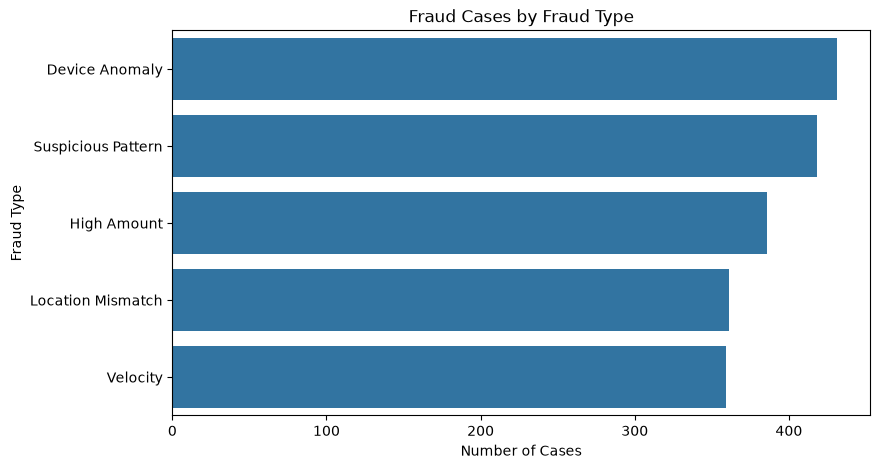

In [80]:
plt.figure(figsize=(9, 5))

sns.countplot(
    data=fraud_cases,
    y='fraud_type',
    order=fraud_cases['fraud_type'].value_counts().index
)

plt.title("Fraud Cases by Fraud Type")
plt.xlabel("Number of Cases")
plt.ylabel("Fraud Type")
plt.show()

In [81]:
fraud_cases['status'].value_counts()

status
Confirmed         951
Under Review      591
False Positive    413
Name: count, dtype: int64

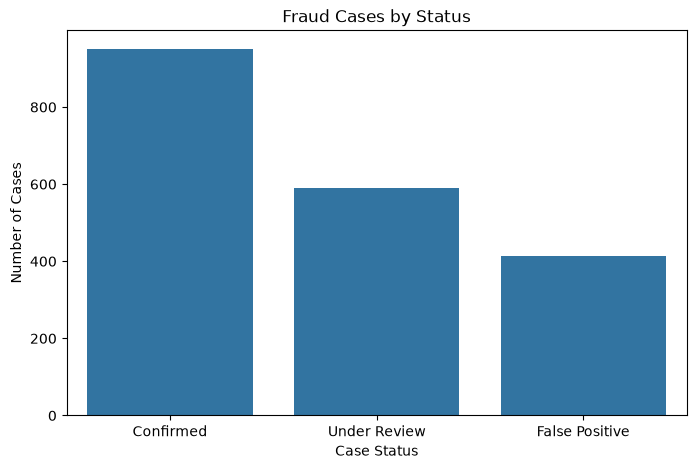

In [82]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=fraud_cases,
    x='status',
    order=fraud_cases['status'].value_counts().index
)

plt.title("Fraud Cases by Status")
plt.xlabel("Case Status")
plt.ylabel("Number of Cases")
plt.show()

In [83]:
fraud_cases['fraud_amount'].describe()

count      1955.000000
mean      52001.055734
std       53192.687745
min         507.560000
25%       14681.050000
50%       30708.850000
75%       70769.345000
max      199815.750000
Name: fraud_amount, dtype: float64

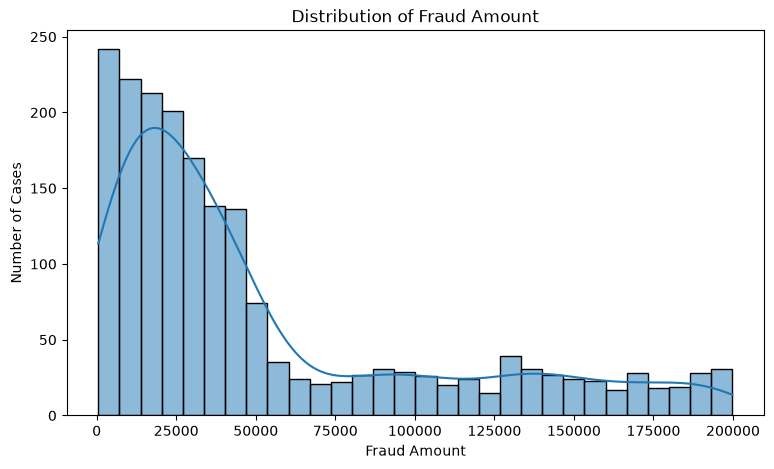

In [84]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=fraud_cases,
    x='fraud_amount',
    bins=30,
    kde=True
)

plt.title("Distribution of Fraud Amount")
plt.xlabel("Fraud Amount")
plt.ylabel("Number of Cases")
plt.show()

In [85]:
fraud_cases.info()

<class 'pandas.DataFrame'>
RangeIndex: 1955 entries, 0 to 1954
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   case_id         1955 non-null   str    
 1   transaction_id  1955 non-null   str    
 2   customer_id     1955 non-null   str    
 3   fraud_amount    1955 non-null   float64
 4   detection_time  1955 non-null   str    
 5   fraud_type      1955 non-null   str    
 6   status          1955 non-null   str    
 7   investigator    999 non-null    str    
dtypes: float64(1), str(7)
memory usage: 285.3 KB


In [86]:
fraud_cases['detection_time'] = pd.to_datetime(fraud_cases['detection_time'])

print(fraud_cases['detection_time'].dtype)

datetime64[us]


In [87]:
fraud_cases['detection_date'] = fraud_cases['detection_time'].dt.date

fraud_cases['detection_date'].value_counts().sort_index().head(10)

detection_date
2026-08-03    10
2026-08-04    69
2026-08-05    62
2026-08-06    59
2026-08-07    54
2026-08-08    79
2026-08-09    77
2026-08-10    74
2026-08-11    65
2026-08-12    56
Name: count, dtype: int64

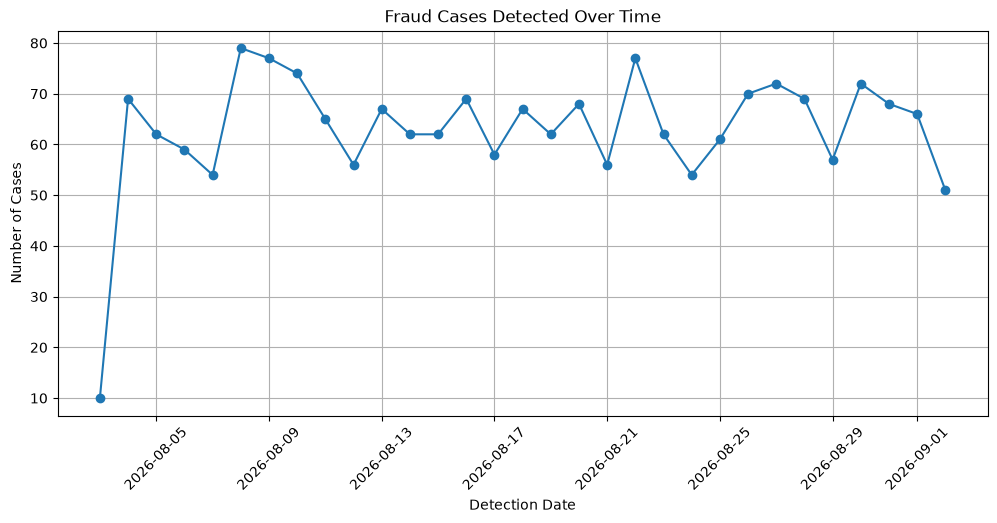

In [88]:
daily_cases = fraud_cases.groupby('detection_date').size()

plt.figure(figsize=(12, 5))

plt.plot(daily_cases.index, daily_cases.values, marker='o')

plt.title("Fraud Cases Detected Over Time")
plt.xlabel("Detection Date")
plt.ylabel("Number of Cases")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

In [89]:
case_transaction_check = fraud_cases.merge(
    df[['transaction_id', 'amount', 'is_fraud']],
    on='transaction_id',
    how='left'
)

case_transaction_check[['fraud_amount', 'amount', 'is_fraud']].head()

,fraud_amount,amount,is_fraud
0,134960.11,NaN,NaN
1,35381.62,NaN,NaN
2,28093.77,28093.77,1.0
3,194942.10,NaN,NaN
4,25678.05,25678.05,1.0


In [90]:
print("Total fraud cases:", len(fraud_cases))
print("Matched transactions:", case_transaction_check['amount'].notna().sum())
print("Unmatched transactions:", case_transaction_check['amount'].isna().sum())

Total fraud cases: 1955
Matched transactions: 1061
Unmatched transactions: 894


In [91]:
case_transaction_check[
    case_transaction_check['amount'].notna()
]['is_fraud'].value_counts()

is_fraud
1.0    1061
Name: count, dtype: int64

In [92]:
df.columns.tolist()

['transaction_id',
 'customer_id',
 'amount',
 'timestamp',
 'hour',
 'day_of_week',
 'location',
 'merchant_category',
 'is_new_device',
 'device_id',
 'ip_address',
 'is_fraud',
 'transaction_type',
 'card_present',
 'amount_log',
 'is_weekend',
 'actual_hour',
 'actual_day_of_week']

In [93]:
df['is_fraud'].value_counts(normalize=True) * 100

is_fraud
0    98.929429
1     1.070571
Name: proportion, dtype: float64

In [94]:
print("Unique target values:", df['is_fraud'].unique())
print("Missing target values:", df['is_fraud'].isnull().sum())

Unique target values: [0 1]
Missing target values: 0


In [95]:
model_df = df.drop(columns=[
    'transaction_id',
    'customer_id',
    'device_id',
    'ip_address',
    'hour',
    'day_of_week',
    'timestamp'
])

print("Shape:", model_df.shape)
print("Columns:", model_df.columns.tolist())

Shape: (99106, 11)
Columns: ['amount', 'location', 'merchant_category', 'is_new_device', 'is_fraud', 'transaction_type', 'card_present', 'amount_log', 'is_weekend', 'actual_hour', 'actual_day_of_week']


In [96]:
model_df.groupby('is_fraud')[
    ['amount', 'amount_log', 'actual_hour', 'actual_day_of_week']
].mean()

,amount,amount_log,actual_hour,actual_day_of_week
is_fraud,,,,
0,2503.656097,7.241646,11.497618,2.892600
1,16243.367107,9.442095,11.282752,2.898209


In [97]:
model_df.groupby('is_new_device')['is_fraud'].agg(
    total_transactions='count',
    fraud_transactions='sum',
    fraud_rate='mean'
)

,total_transactions,fraud_transactions,fraud_rate
is_new_device,,,
False,98783,738,0.007471
True,323,323,1.000000


In [98]:
model_df.groupby('transaction_type')['is_fraud'].agg(
    total_transactions='count',
    fraud_transactions='sum',
    fraud_rate='mean'
).sort_values('fraud_rate', ascending=False)

,total_transactions,fraud_transactions,fraud_rate
transaction_type,,,
online,24647,302,0.012253
atm,24808,269,0.010843
in-store,24712,245,0.009914
wire,24939,245,0.009824


In [99]:
model_df.groupby('location')['is_fraud'].agg(
    total_transactions='count',
    fraud_transactions='sum',
    fraud_rate='mean'
).sort_values('fraud_rate', ascending=False)

,total_transactions,fraud_transactions,fraud_rate
location,,,
BR,54,54,1.000000
NG,43,43,1.000000
CN,54,54,1.000000
RU,53,53,1.000000
SG,9978,100,0.010022
US,38593,348,0.009017
AU,10560,91,0.008617
IN,19497,162,0.008309
UK,20274,156,0.007695


In [100]:
model_df.groupby('merchant_category')['is_fraud'].agg(
    total_transactions='count',
    fraud_transactions='sum',
    fraud_rate='mean'
).sort_values('fraud_rate', ascending=False)

,total_transactions,fraud_transactions,fraud_rate
merchant_category,,,
E-commerce,16556,183,0.011053
Food,16455,179,0.010878
Entertainment,16546,177,0.010697
Travel,16493,175,0.010611
Services,16557,175,0.010570
Retail,16499,172,0.010425


In [101]:
model_df.groupby('card_present')['is_fraud'].agg(
    total_transactions='count',
    fraud_transactions='sum',
    fraud_rate='mean'
)

,total_transactions,fraud_transactions,fraud_rate
card_present,,,
False,39866,426,0.010686
True,59240,635,0.010719


In [102]:
model_df.groupby('is_weekend')['is_fraud'].agg(
    total_transactions='count',
    fraud_transactions='sum',
    fraud_rate='mean'
)

,total_transactions,fraud_transactions,fraud_rate
is_weekend,,,
0,70686,753,0.010653
1,28420,308,0.010837


In [103]:
model_df.groupby('is_fraud')['amount_log'].agg(
    ['count', 'mean', 'median', 'min', 'max']
)

,count,mean,median,min,max
is_fraud,,,,,
0,98045,7.241646,7.536775,1.793425,9.203959
1,1061,9.442095,9.681133,6.231583,10.445411


In [104]:
df_merged.groupby('is_fraud')[
    [
        'account_age_days',
        'risk_score',
        'avg_monthly_transactions',
        'avg_transaction_amount',
        'device_count'
    ]
].mean()

,account_age_days,risk_score,avg_monthly_transactions,avg_transaction_amount,device_count
is_fraud,,,,,
0,1824.842256,0.495952,52.007935,2504.006985,2.479331
1,1896.068803,0.490808,52.544769,2493.304203,2.476909


In [105]:
df_merged.groupby('segment')['is_fraud'].agg(
    total_transactions='count',
    fraud_transactions='sum',
    fraud_rate='mean'
).sort_values('fraud_rate', ascending=False)

,total_transactions,fraud_transactions,fraud_rate
segment,,,
Premium,19453,223,0.011464
Business,29687,315,0.010611
Retail,40364,425,0.010529
Student,9602,98,0.010206


In [106]:
df_merged.groupby('email_verified')['is_fraud'].agg(
    total_transactions='count',
    fraud_transactions='sum',
    fraud_rate='mean'
)

,total_transactions,fraud_transactions,fraud_rate
email_verified,,,
False,19412,214,0.011024
True,79694,847,0.010628


In [107]:
df_merged.groupby('phone_verified')['is_fraud'].agg(
    total_transactions='count',
    fraud_transactions='sum',
    fraud_rate='mean'
)

,total_transactions,fraud_transactions,fraud_rate
phone_verified,,,
False,29661,310,0.010451
True,69445,751,0.010814


In [108]:
df_merged.groupby('location_match')['is_fraud'].agg(
    total_transactions='count',
    fraud_transactions='sum',
    fraud_rate='mean'
)

,total_transactions,fraud_transactions,fraud_rate
location_match,,,
False,204,204,1.000000
True,98902,857,0.008665


In [109]:
df_merged.groupby('location_y')['is_fraud'].agg(
    total_transactions='count',
    fraud_transactions='sum',
    fraud_rate='mean'
).sort_values('fraud_rate', ascending=False)

,total_transactions,fraud_transactions,fraud_rate
location_y,,,
SG,9996,118,0.011805
US,38687,442,0.011425
IN,19532,197,0.010086
AU,10574,105,0.009930
UK,20317,199,0.009795


In [110]:
ml_df = df_merged[[
    'amount',
    'location_x',
    'merchant_category',
    'is_new_device',
    'transaction_type',
    'card_present',
    'amount_log',
    'is_weekend',
    'actual_hour',
    'actual_day_of_week',
    'location_match',
    'segment',
    'account_age_days',
    'risk_score',
    'email_verified',
    'phone_verified',
    'avg_monthly_transactions',
    'avg_transaction_amount',
    'device_count',
    'is_fraud'
]].copy()

print("Shape:", ml_df.shape)
print("Columns:", ml_df.columns.tolist())

Shape: (99106, 20)
Columns: ['amount', 'location_x', 'merchant_category', 'is_new_device', 'transaction_type', 'card_present', 'amount_log', 'is_weekend', 'actual_hour', 'actual_day_of_week', 'location_match', 'segment', 'account_age_days', 'risk_score', 'email_verified', 'phone_verified', 'avg_monthly_transactions', 'avg_transaction_amount', 'device_count', 'is_fraud']


In [111]:
ml_df = ml_df.drop(columns=['amount_log'])

print("Shape:", ml_df.shape)
print("Columns:", ml_df.columns.tolist())

Shape: (99106, 19)
Columns: ['amount', 'location_x', 'merchant_category', 'is_new_device', 'transaction_type', 'card_present', 'is_weekend', 'actual_hour', 'actual_day_of_week', 'location_match', 'segment', 'account_age_days', 'risk_score', 'email_verified', 'phone_verified', 'avg_monthly_transactions', 'avg_transaction_amount', 'device_count', 'is_fraud']
